In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline


In [2]:
!pwd

/mnt/c/Users/alejandro.gomez/Documents/driver_behavior/src/Notebooks


In [26]:
path1 = '../experiments/old/2026-05-08/14-34-19/main.log'
path2 = '../experiments/2026-05-15/16-00-35/main.log'
file1 = np.loadtxt(path1, delimiter=';', skiprows=10, dtype=str)
file2 = np.loadtxt(path2, delimiter=';', skiprows=10, dtype=str)

/tmp/ipykernel_4129216/3286922161.py:3: UserWarning: Input line 1335 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  file1 = np.loadtxt(path1, delimiter=';', skiprows=10, dtype=str)
/tmp/ipykernel_4129216/3286922161.py:4: UserWarning: Input line 1335 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore

In [43]:
epochs = dict()
test_epochs = dict()
last_id = -1
idx = 0
for i in file1:
    if 'Train' in i:
        idx = int(str(i).split('Epoch: ')[1].split(' ')[0])
        if epochs.get(idx) is None:
            epochs[idx] = [float(i.split('Loss: ')[-1])]
        else:
            epochs[idx].append(float(i.split('Loss: ')[-1]))
        if last_id != idx:
            last_id = idx
    elif 'Test' in i:
        test_epochs[idx] = float(i.split(',')[0].split(' ')[-1])
"""
last_id +=1
for i in file2:
     if 'Train' in i:
        idx = int(str(i).split('Epoch: ')[1].split(' ')[0] ) + last_id
        if epochs.get(idx) is None:
            epochs[idx] = [float(i.split('Loss: ')[-1])]
        else:
            epochs[idx].append(float(i.split('Loss: ')[-1]))
     elif 'Test' in i:
        test_epochs[idx] = float(i.split(',')[0].split(' ')[-1])

if last_id != idx:
    last_id = idx
"""

In [44]:
test_epochs

{0: 0.0076,
 1: 0.0056,
 2: 0.003,
 3: 0.0022,
 4: 0.002,
 5: 0.0015,
 6: 0.0008,
 7: 0.0008,
 9: 0.0006,
 10: 0.0008,
 11: 0.0006,
 12: 0.0005,
 13: 0.0004}

In [45]:
for k in epochs.keys():
    epochs[k] = sum(epochs[k])/len(epochs[k])
epochs

{0: 0.7670434878971255,
 1: 0.36260658472012103,
 2: 0.23960968835098334,
 3: 0.16900608698941,
 4: 0.11579954992435704,
 5: 0.08079491074130106,
 6: 0.05823553403933434,
 7: 0.04619080711043873,
 8: 0.037384398089171975,
 9: 0.038881517397882,
 10: 0.03143192889561271,
 11: 0.027839068078668688,
 12: 0.023996297276853252,
 13: 0.019437956883509834,
 14: 0.018897084615384613}

Text(0.5, 1.0, 'Loss')

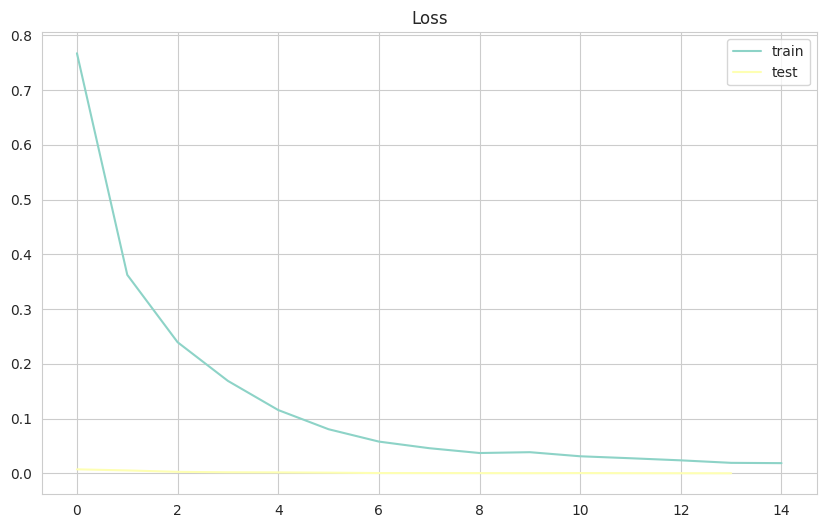

In [52]:
/plt.figure(figsize=(10, 6))
plt.plot(epochs.keys(), epochs.values(), label='train')
plt.plot(test_epochs.keys(), test_epochs.values(), label='test')
plt.legend()
plt.title('Loss')

Text(0.5, 1.0, 'Loss')

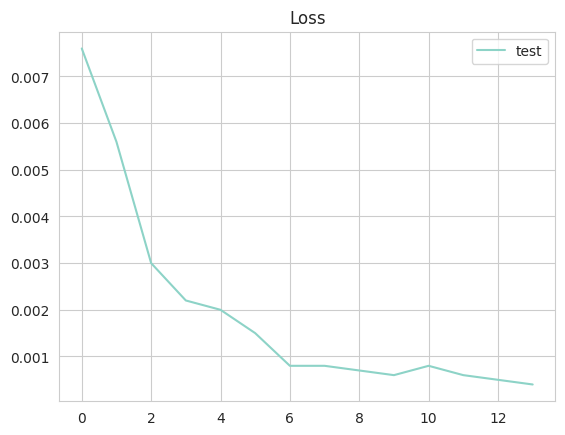

In [51]:

plt.plot(test_epochs.keys(), test_epochs.values(), label='test')
plt.legend()
plt.title('Loss')